## Replication of Bursztyn et al. (2022): Opinions as Facts

**The paper:**
The goal of this paper is to ...

**Disclaimer:**
In this notebook, I replicate the key results from Bursztyn et al. (2022). In my attempt to use the scripts included in the original replication package provided by the authors, I often run into package compatibility issues which prevented the execution of the code. The scripts incorporated in this notebook are adapted accordingly, in ways that ae not expected to affect the essence and results of the original code. The changes made are mentioned in the README file.

This notebook follows the logic of the paper and does not cover any results included in the Supplementary material provided by the authors. 



### *Trust in opinion shows*

In this section, the authors provide evidence that people turn to opinion shows over straight news to learn about objective facts. 

This sets the ground for studying the causal effect of diverging narratives held by opinion shows, in shaping beliefs and subsequently behaviors and outcomes in high-stakes situations where relying on objective and accurate information is crucial. The early stages of the COVID-19 pandemic in the US fits exactly that profile.

In [1]:
####################################
# global libraries used everywhere #
####################################

# Set CRAN mirror
options(repos = c(CRAN = "https://cran.rstudio.com/"))

# mran.date <- "2019-09-01"
# options(repos=paste0("https://cran.microsoft.com/snapshot/",mran.date,"/"))

# Note: Using this with a specific version number may fail, since not all dependencies might be met.
# Debug interactively, then identify all installed packages that needed to be pinned.

quiet_eval <- function(expr) {
  suppressWarnings(
    suppressMessages(
      suppressPackageStartupMessages(expr)
    )
  )
}

quiet_require <- function(pkg) {
  quiet_eval(
    require(pkg, character.only = TRUE, quietly = TRUE, warn.conflicts = FALSE)
  )
}

pkgTest <- function(x, y = "") {
  if (!quiet_require(x)) {
    if (y == "") {
      tryCatch(
        quiet_eval(install.packages(x, dep = TRUE, quiet = TRUE)),
        error = function(e) invisible(NULL)
      )
    } else {
      tryCatch(
        {
          if (!requireNamespace("remotes", quietly = TRUE)) {
            quiet_eval(install.packages("remotes", quiet = TRUE))
          }
          quiet_eval(remotes::install_version(x, y, quiet = TRUE))
        },
        error = function(e) invisible(NULL)
      )
    }

    if (!quiet_require(x)) {
      return(FALSE)
    }
  }
  return(TRUE)
}

global.libraries <- c("tidyverse", "haven", "lfe", "lubridate", "cowplot", "broom",
                      "extrafont", "lubridate", "stringr", "ggpubr", "zoo", "tidyr", "RColorBrewer", "multcomp",
                      "fixest", "pscl", "statar", "doParallel", "gridExtra", "tmap", "sf", "cutr",
                      "splines", "stargazer", "rjson")

results <- quiet_eval(vapply(global.libraries, pkgTest, logical(1)))
names(results) <- global.libraries

# Optional: install stargazer booktabs fork for specific table formatting
if (interactive()) {
  tryCatch(
    {
      if (!requireNamespace("remotes", quietly = TRUE)) {
        quiet_eval(install.packages("remotes", quiet = TRUE))
      }
      quiet_eval(remotes::install_github(
        "markwestcott34/stargazer-booktabs",
        force = TRUE,
        quiet = TRUE
      ))
    },
    error = function(e) invisible(NULL)
  )
}

# Font (run once if needed)
if (!requireNamespace("extrafont", quietly = TRUE)) {
  quiet_eval(install.packages("extrafont", quiet = TRUE))
}
quiet_eval(library(extrafont))
tryCatch(
  quiet_eval(font_import(pattern = "lmodern*", prompt = FALSE)),
  error = function(e) invisible(NULL)
)

invisible(results)

#### Figure 1 & Table 1: Trust in opinions ####

`summarise()` has grouped output by 'outcome', 'incentive'. You can override
using the `.groups` argument.


Trust in opinion shows 
 Dependent variable: 
 
 Respondent chose opinion show 
 COVID-19 Economy GDP Earnings Unemployment Pooled 
 (1) (2) (3) (4) (5) (6) 
 incentive -0.022 -0.010 0.006 -0.049 -0.124 -0.027 
 (0.104) (0.098) (0.096) (0.101) (0.093) (0.039) 
 
 Dep.~var.~mean 0.748 0.759 0.741 0.735 0.739 0.745 
 Observations 107 112 112 102 115 548 
 R 2 0.288 0.260 0.273 0.296 0.290 0.065 
 Adjusted R 2 -0.020 -0.027 0.004 -0.001 0.025 0.005 
 Residual Std. Error 0.441 (df = 74) 0.435 (df = 80) 0.439 (df = 81) 0.444 (df = 71) 0.436 (df = 83) 0.435 (df = 514) 
 F Statistic 0.935 (df = 32; 74) 0.907 (df = 31; 80) 1.014 (df = 30; 81) 0.996 (df = 30; 71) 1.094 (df = 31; 83) 1.084 (df = 33; 514) 
 Note: * p<0.1; ** p<0.05; *** p<0.01 
 
 

 Trust in opinion shows 
 Dependent variable: 
 
 Respondent chose opinion show 
 COVID-19 Economy GDP Earnings Unemployment Pooled 
 (1) (2) (3) (4) (5) (6) 
 incentive 0.107 -0.072 0.091 -0.014 0.095 0.058 
 (0.111) (0.113) (0.117) (0.109) (0.115) (0.045) 
 
 Dep.~var.~mean 0.534 0.592 0.604 0.616 0.683 0.606 
 Observations 103 98 101 99 104 505 
 R 2 0.372 0.347 0.328 0.422 0.280 0.089 
 Adjusted R 2 0.084 0.054 0.026 0.155 -0.030 0.025 
 Residual Std. Error 0.480 (df = 70) 0.481 (df = 67) 0.485 (df = 69) 0.449 (df = 67) 0.475 (df = 72) 0.483 (df = 471) 
 F Statistic 1.293 (df = 32; 70) 1.184 (df = 30; 67) 1.085 (df = 31; 69) 1.580 * (df = 31; 67) 0.902 (df = 31; 72) 1.386 * (df = 33; 471) 
 Note: * p<0.1; ** p<0.05; *** p<0.01

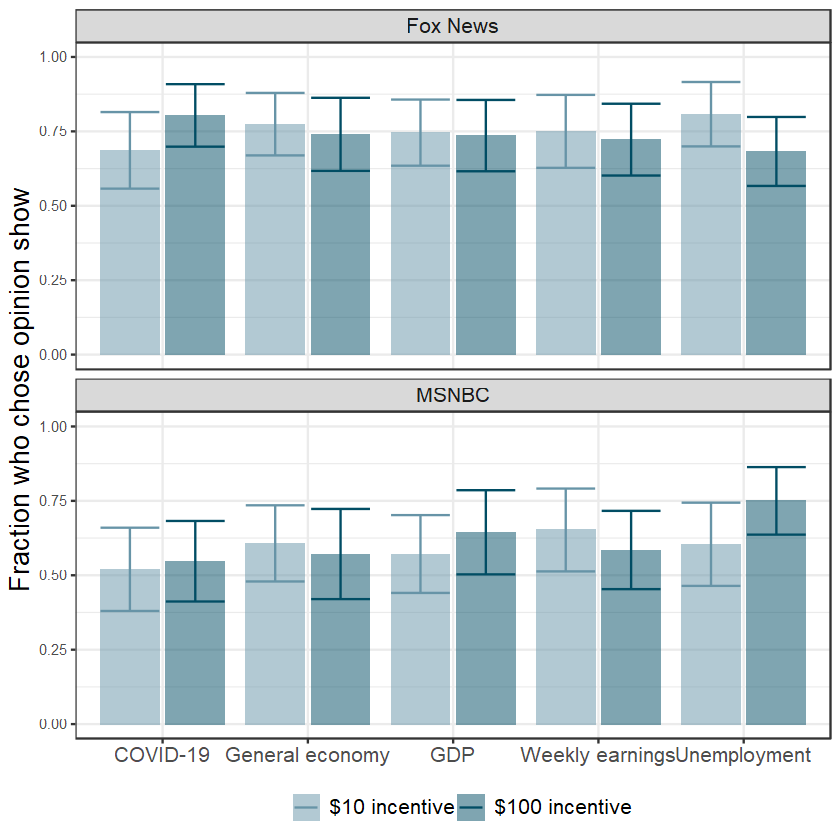

In [9]:
##########
# CREATE TRUST FIGURE AND TABLE
##########

library(tidyverse)
library(stringr)
library(stargazer)
library(haven)
library(extrafont)

tablenotes = rjson::fromJSON(file='../code/analysis/tablenotes.json')


# Read and prepare trust survey data
trust <- read_dta('../data/working/trust-survey.dta') %>% 
  mutate(highincentive=amount==100,
         outcome = factor(outcome, levels = c('covid', 'general','gdp','earnings','unemployment'),
                          labels = c('COVID-19','General economy','GDP','Weekly earnings','Unemployment')),
         incentive = ifelse(highincentive, '$100 incentive', '$10 incentive'))


# Trust figure
summary = trust %>% group_by(outcome, incentive, experiment) %>% 
  summarise(mean = mean(chose_opinion, na.rm=T),
            se = sd(chose_opinion, na.rm=T)/sqrt(n())) %>% 
  mutate(eh = mean+1.96*se, el = mean-1.96*se)

ggplot(summary, aes(x = outcome, y = mean, fill=incentive)) +
  geom_bar(stat='identity', position = position_dodge2(), alpha=0.5) +
  scale_fill_manual(values=c("#6794a7", "#014d64")) +
  geom_errorbar(aes(ymin = mean-1.96*se, ymax=mean+1.96*se, col = incentive), position = position_dodge2()) + 
  scale_color_manual(values=c("#6794a7", "#014d64")) +
  coord_cartesian(ylim=c(0, 1)) +
  facet_wrap(~experiment, ncol=1) +
  theme_bw() +
  theme(legend.position = 'bottom',
        legend.text=element_text(size=12),
        legend.title=element_text(size=12),
        axis.text.x = element_text(size=12),
        axis.title.y = element_text(size=16),
        strip.text.x = element_text(size=12),
        axis.title.x = element_blank(),
          text = element_text(family='sans')) +
  labs(fill = '', col= '') +
  xlab('Outcome') +
  ylab('Fraction who chose opinion show') 

ggsave('../output/figures/trust.png', height=7, width=7)


# Trust table

controls = 'age+gender+employ+hhi+race+hisp+educ'

create_panel = function(x, type = 'latex') {
  m1=lm(str_interp('chose_opinion~highincentive+${controls}'), data=x %>% filter(outcome=='COVID-19'))
  m2=lm(str_interp('chose_opinion~highincentive+${controls}'), data=x %>% filter(outcome=='General economy'))
  m3=lm(str_interp('chose_opinion~highincentive+${controls}'), data=x %>% filter(outcome=='GDP'))
  m4=lm(str_interp('chose_opinion~highincentive+${controls}'), data=x %>% filter(outcome=='Weekly earnings'))
  m5=lm(str_interp('chose_opinion~highincentive+${controls}'), data=x %>% filter(outcome=='Unemployment'))
  m6=lm(str_interp('chose_opinion~highincentive+${controls}'), data=x)
  
  means = map_dbl(c('COVID-19','General economy','GDP','Weekly earnings','Unemployment'), function(y) mean(x$chose_opinion[x$outcome==y], na.rm=T))
  means = c(means, mean(x$chose_opinion, na.rm=T)) %>% round(3) %>% format(nsmall=3) 
  
  capture.output(stargazer(list(m1, m2, m3, m4, m5, m6),
            type = type,
            column.labels = c('COVID-19','Economy','GDP','Earnings','Unemployment', 'Pooled'),
            keep = 'highincentive',
            dep.var.labels = 'Respondent chose opinion show',
            title = 'Trust in opinion shows',
            label = 't:trust-experiment',
            add.lines = list(c('Dep.~var.~mean', means)),
            covariate.labels = '\\$100 incentive'))
}

foxpanel = create_panel(trust %>% filter(experiment=='Fox News'))
msnbcpanel = create_panel(trust %>% filter(experiment=='MSNBC'))


table = c(
  foxpanel[4:6],
  '\\begin{threeparttable}',
  foxpanel[7:15],
  '\\multicolumn{7}{l}{\\textbf{Panel A}: Fox News viewers} \\\\',
  '\\midrule',
  foxpanel[c(16:18, 20:21)],
  '\\midrule',
  '\\multicolumn{7}{l}{\\textbf{Panel B}: MSNBC viewers} \\\\',
  '\\midrule',
  msnbcpanel[c(16:18, 20:21)],
  msnbcpanel[26],
  '\\midrule',
  msnbcpanel[28],
  '\\begin{tablenotes} \\small',
  paste0('\\item \\textit{Notes:} ', str_interp(tablenotes[['t:trust-experiment']])),
  '\\end{tablenotes} \\end{threeparttable} \\end{table}'
)

invisible(write_lines(table, '../output/tables/trust.tex'))
if (requireNamespace('IRdisplay', quietly = TRUE)) IRdisplay::display_html(paste(c(create_panel(trust %>% filter(experiment=='Fox News'), type='html'), '<br/>', create_panel(trust %>% filter(experiment=='MSNBC'), type='html')), collapse='\n'))